In [6]:
"""
PINN for the 1D heat equation:
    u_t = alpha * u_xx,  x in [0,1], t in [0,1]
    u(x, 0) = sin(pi*x)          (initial condition)
    u(0, t) = u(1, t) = 0        (Dirichlet BCs)

Exact solution: u(x,t) = exp(-alpha * pi^2 * t) * sin(pi*x)
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [7]:
ALPHA = 0.1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        stack = []
        for i in range(len(layers) - 1):
            stack.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                stack.append(nn.Tanh())
        self.net = nn.Sequential(*stack)

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

In [9]:
def exact(x, t):
    return torch.exp(-ALPHA * np.pi**2 * t) * torch.sin(np.pi * x)


def sample_collocation(n):
    x = torch.rand(n, 1, device=DEVICE, requires_grad=True)
    t = torch.rand(n, 1, device=DEVICE, requires_grad=True)
    return x, t


def sample_ic(n):
    x = torch.rand(n, 1, device=DEVICE)
    t = torch.zeros(n, 1, device=DEVICE)
    u = torch.sin(np.pi * x)
    return x, t, u


def sample_bc(n):
    t = torch.rand(n, 1, device=DEVICE)
    x0 = torch.zeros(n, 1, device=DEVICE)
    x1 = torch.ones(n, 1, device=DEVICE)
    return x0, x1, t


def pde_residual(model, x, t):
    u = model(x, t)
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    return u_t - ALPHA * u_xx

In [10]:
def train(epochs=5000, n_col=2000, n_ic=500, n_bc=500, lr=1e-3):
    model = PINN([2, 64, 64, 64, 1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

    history = []

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        # PDE loss
        x_col, t_col = sample_collocation(n_col)
        res = pde_residual(model, x_col, t_col)
        loss_pde = (res**2).mean()

        # Initial condition loss
        x_ic, t_ic, u_ic = sample_ic(n_ic)
        loss_ic = ((model(x_ic, t_ic) - u_ic) ** 2).mean()

        # Boundary condition loss
        x0, x1, t_bc = sample_bc(n_bc)
        loss_bc = ((model(x0, t_bc)) ** 2).mean() + ((model(x1, t_bc)) ** 2).mean()

        loss = loss_pde + 10 * loss_ic + 10 * loss_bc
        loss.backward()
        optimizer.step()
        scheduler.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch:5d} | loss={loss.item():.2e} | pde={loss_pde.item():.2e} | ic={loss_ic.item():.2e} | bc={loss_bc.item():.2e}")
            history.append((epoch, loss.item()))

    return model, history

In [15]:
def evaluate_and_plot(model):
    nx, nt = 100, 100
    x = torch.linspace(0, 1, nx, device=DEVICE).unsqueeze(1)
    t = torch.linspace(0, 1, nt, device=DEVICE).unsqueeze(1)
    X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")

    with torch.no_grad():
        x_flat = X.reshape(-1, 1)
        t_flat = T.reshape(-1, 1)
        u_pred = model(x_flat, t_flat).reshape(nx, nt).cpu().numpy()

    u_exact = exact(X, T).cpu().numpy()
    error = np.abs(u_pred - u_exact)
    print(f"\nMax absolute error : {error.max():.4e}")
    print(f"Mean absolute error: {error.mean():.4e}")

    X_np = X.cpu().numpy()
    T_np = T.cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    im0 = axes[0].contourf(T_np, X_np, u_exact, levels=50, cmap="RdBu_r")
    axes[0].set_title("Exact solution")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("x")
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].contourf(T_np, X_np, u_pred, levels=50, cmap="RdBu_r")
    axes[1].set_title("PINN prediction")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("x")
    fig.colorbar(im1, ax=axes[1])

    im2 = axes[2].contourf(T_np, X_np, error, levels=50, cmap="hot_r")
    axes[2].set_title("Absolute error")
    axes[2].set_xlabel("t")
    axes[2].set_ylabel("x")
    fig.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()

In [12]:
print(f"Device: {DEVICE}")
print(f"Training PINN for 1D heat equation (alpha={ALPHA})...\n")
model, history = train()

Device: cuda
Training PINN for 1D heat equation (alpha=0.1)...



/home/dakoro/Github/ai-experiments/.venv/lib/python3.10/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch   500 | loss=3.70e-03 | pde=2.78e-03 | ic=4.91e-05 | bc=4.30e-05
Epoch  1000 | loss=9.13e-04 | pde=7.94e-04 | ic=4.34e-06 | bc=7.57e-06
Epoch  1500 | loss=5.86e-04 | pde=4.12e-04 | ic=7.32e-06 | bc=1.00e-05
Epoch  2000 | loss=2.41e-04 | pde=2.13e-04 | ic=1.04e-06 | bc=1.76e-06
Epoch  2500 | loss=1.93e-04 | pde=1.72e-04 | ic=7.99e-07 | bc=1.37e-06
Epoch  3000 | loss=1.66e-04 | pde=1.47e-04 | ic=7.35e-07 | bc=1.16e-06
Epoch  3500 | loss=2.05e-04 | pde=1.32e-04 | ic=2.54e-06 | bc=4.68e-06
Epoch  4000 | loss=1.96e-04 | pde=1.11e-04 | ic=3.74e-06 | bc=4.78e-06
Epoch  4500 | loss=1.12e-04 | pde=1.01e-04 | ic=5.08e-07 | bc=5.58e-07
Epoch  5000 | loss=1.18e-04 | pde=1.09e-04 | ic=4.84e-07 | bc=3.96e-07



Max absolute error : 2.3573e-03
Mean absolute error: 5.5176e-04


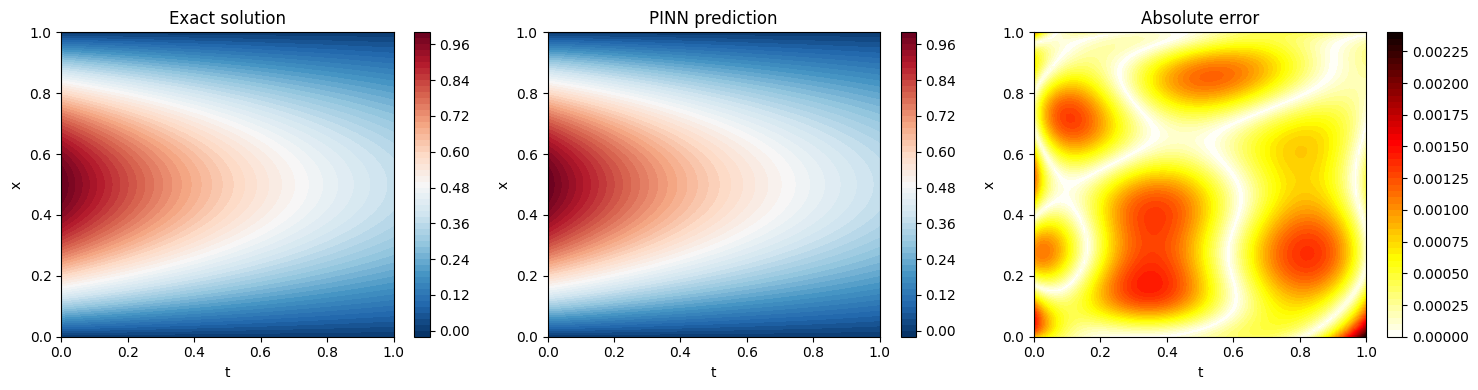

In [16]:
evaluate_and_plot(model)